# Regresión Logística — notebook auxiliar
**Aprendizaje de Máquina - CEIA - FIUBA**

*Notebook auxiliar (no forma parte del flujo de clase).*

En las notebooks de búsqueda de hiperparámetros entrenamos el baseline de glucosa y varias variantes de KNN. Faltaba un modelo lineal clásico e interpretable: la **regresión logística**.

Este notebook entrena una regresión logística sobre el dataset **Pima Indians Diabetes** usando **exactamente el mismo split** que el resto de las notebooks, de modo que sus métricas sean directamente comparables.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set()

## Datos y split

Mismo dataset y mismo split que las notebooks de hiperparámetros. Los ceros (glucosa, insulina, imc, ...) se mantienen sin imputar, tal como en el resto de las notebooks.

In [2]:
pima_df = pd.read_csv("./datasets/pima_diabetes.csv")

X = pima_df.drop("diabetes", axis=1).values
y = pima_df["diabetes"].values
feature_names = pima_df.drop("diabetes", axis=1).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
    random_state=0, stratify=y)

print("Número de muestras (train):", X_train.shape[0])
print("Número de features:", X_train.shape[1])

Número de muestras (train): 576
Número de features: 8


## Búsqueda de hiperparámetros

La regresión logística tiene pocos hiperparámetros relevantes: la fuerza de regularización `C`, el tipo de penalización (`l1` o `l2`) y —dado el **desbalance de clases**— `class_weight` (`None` vs `'balanced'`, que repondera la clase minoritaria de forma inversamente proporcional a su frecuencia). Usamos una búsqueda por grilla con validación cruzada de 5-Fold, maximizando el F1-score (la misma métrica que en el resto de las notebooks, por el desbalance de clases).

Envolvemos el modelo en un `Pipeline` con `StandardScaler` para estandarizar dentro de cada fold y evitar fuga de información.

In [3]:
clf_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

hyperparams = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0, 1],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced"],
}

grid = GridSearchCV(clf_logreg,
                    hyperparams,
                    refit=True,
                    cv=5,
                    scoring='f1',
                    n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0, 1], 'model__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True

In [4]:
grid.best_params_

{'model__C': 1,
 'model__class_weight': 'balanced',
 'model__l1_ratio': 1,
 'model__solver': 'liblinear'}

Elegido el mejor modelo, lo evaluamos sobre el conjunto de testeo.

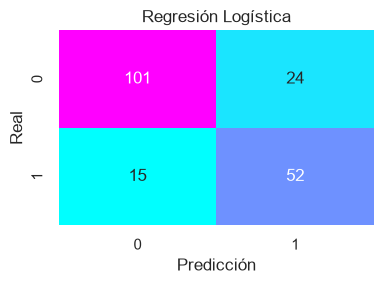

In [5]:
best_logreg = grid.best_estimator_

y_pred = best_logreg.predict(X_test)
cm_logreg = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Regresión Logística")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

In [6]:
TN, FP, FN, TP = cm_logreg.ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Regresión Logística")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred, zero_division=0):.4f}")

Regresión Logística
Sensibilidad (Recall): 0.7761
Especificidad:         0.8080
Exactitud balanceada:  0.7921
Precisión:             0.6842
Recall:                0.7761
F1-score:              0.7273


## Interpretación de los coeficientes

Una ventaja de la regresión logística es su interpretabilidad: cada coeficiente indica cómo cambia el log-odds de tener diabetes ante un aumento de una desviación estándar de cada feature (los datos están estandarizados). Coeficientes positivos empujan hacia la clase "con diabetes".

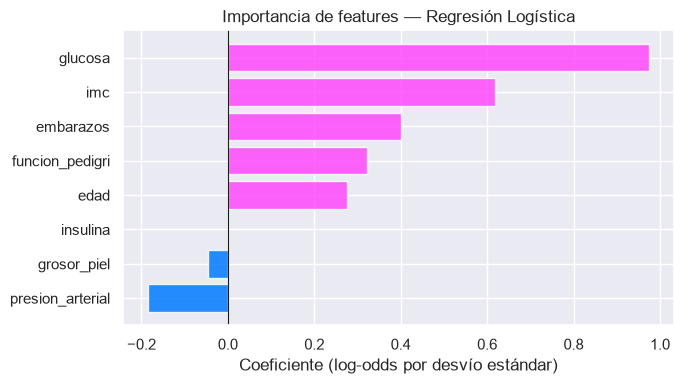

In [7]:
coefs = best_logreg.named_steps['model'].coef_.ravel()
orden = np.argsort(coefs)

fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#ff48fd' if c > 0 else '#007aff' for c in coefs[orden]]
ax.barh(np.array(feature_names)[orden], coefs[orden], color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Coeficiente (log-odds por desvío estándar)")
ax.set_title("Importancia de features — Regresión Logística")
plt.tight_layout()
plt.show()

## Comparativa contra el baseline

Comparamos contra el baseline heurístico de umbral de glucosa.

In [8]:
# Baseline: umbral de glucosa (glucosa es la columna 1)
glucosa_sin = pima_df.loc[pima_df["diabetes"] == 0, "glucosa"]
glucosa_con = pima_df.loc[pima_df["diabetes"] == 1, "glucosa"]
umbral_glucosa = (glucosa_sin.median() + glucosa_con.median()) / 2

y_pred_baseline = (X_test[:, 1] > umbral_glucosa).astype(int)

modelos = ["Baseline (umbral glucosa)", "Regresión Logística"]
preds = [y_pred_baseline, y_pred]

df_cmp = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds],
}, index=pd.Index(modelos))

df_cmp.round(4)

,F1-score,Exactitud balanceada,Precisión,Recall
Baseline (umbral glucosa),0.6533,0.7297,0.5904,0.7313
Regresión Logística,0.7273,0.7921,0.6842,0.7761
